In [1]:
PALETTE = [
    "#5F4690",
    "#1D6996",
    "#38A6A5",
    "#0F8554",
    "#73AF48",
    "#EDAD08",
    "#E17C05",
    "#CC503E",
    "#94346E",
    "#6F4070",
    "#994E95",
    "#FF89F9",
    "#FBC5F9",
    "#666666",
]

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MultipleLocator
from tueplots import bundles, figsizes

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [14]:
metrics = ['nice_factor', 'forgiving_factor', 'retaliatory_factor', 'troublemaking_factor', 'emulative_factor']
x_axis_names = {
    'nice_factor': 'Nice',
    'forgiving_factor': 'Forgiving',
    'retaliatory_factor': 'Retaliatory',
    'troublemaking_factor': 'Troublemaking',
    'emulative_factor': 'Emulative',
}
metric_colors = {
    'nice_factor': PALETTE[4],
    'forgiving_factor': PALETTE[2],
    'retaliatory_factor': PALETTE[7],
    'troublemaking_factor': PALETTE[1],
    'emulative_factor': PALETTE[9],
}
models = ['ministral-3:8b', 'ministral-3:14b', 'qwen3.5:9b']
model_names = {
    'ministral-3:8b': 'Ministral 3 8B',
    'ministral-3:14b': 'Ministral 3 14B',
    'qwen3.5:9b': 'Qwen 3.5 9B',
}

prompt_files = [
    'prompts/baseline.json',
]
prompt_file_names = {
    'prompts/baseline.json': 'Baseline',
}

In [16]:
df = pd.read_csv("results/analyzed_results.csv")
agg_df = (
    df.groupby(['model', 'prompt_file'], as_index=False)
      .agg({
          metric: 'mean' for metric in metrics
      })
)
print(agg_df)

             model                 prompt_file  nice_factor  forgiving_factor  \
0  ministral-3:14b       prompts/baseline.json          1.0          0.095828   
1  ministral-3:14b  prompts/compassionate.json          1.0          0.576522   
2  ministral-3:14b   prompts/narcissistic.json          0.0          0.000000   
3   ministral-3:8b       prompts/baseline.json          0.0          0.002658   
4   ministral-3:8b  prompts/compassionate.json          1.0          0.817852   
5   ministral-3:8b   prompts/narcissistic.json          0.0          0.000000   
6       qwen3.5:9b       prompts/baseline.json          0.4          0.175508   
7       qwen3.5:9b  prompts/compassionate.json          0.8          0.873823   
8       qwen3.5:9b   prompts/narcissistic.json          0.0          0.014903   

   retaliatory_factor  troublemaking_factor  emulative_factor  
0            0.944923              0.717241          0.537879  
1            0.563723              0.240236          0.682828

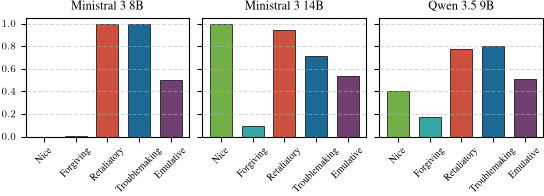


Saved to plots/baselines.pdf


In [15]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.1, rel_width=1))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})



os.makedirs("plots", exist_ok=True)

colors = [PALETTE[2], PALETTE[7], PALETTE[2], PALETTE[7]]

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models, axes):
    model_metrics = agg_df[(agg_df["model"] == model) & (agg_df["prompt_file"] == prompt_files[0])].iloc[0]
    model_metrics = [model_metrics[metric] for metric in metrics]
    colors = [metric_colors[metric] for metric in metrics]
    x = np.arange(len(model_metrics))
    bars = ax.bar(x, model_metrics, color=colors,
                      edgecolor="black", linewidth=0.5, width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([x_axis_names[metric] for metric in metrics], rotation=45, ha="center")
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")
    ax.set_title(model_names[model])

plt.savefig("plots/baselines.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/baselines.pdf")